# __2.4 Деревья в теории графов__

Алгоритм Дейкстры

In [1]:
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt

In [ ]:
def dijkstra(G, start):
    import heapq


    N = len(G)

    # Куча минимумов для быстрого поиска непосещенной вершины с наименьшим расстоянием
    heap = []
    heapq.heappush(heap, (0, start))

    # Инициализация массива расстояний
    dist = [float('inf')] * N
    dist[start] = 0

    # Инициализация массива меток
    mark = [0] * N

    # Инициализация массива предков
    prev = [-1] * N
    
    while heap:
        cur_dist, u = heapq.heappop(heap)

        if mark[u]: 
            continue

        mark[u] = 1

        for v in range(N):
            if not mark[v] and G[u][v] != 0:
                new_dist = cur_dist + G[u][v]

                if new_dist < dist[v]:
                    dist[v] = new_dist
                    prev[v] = u
                    heapq.heappush(heap, (new_dist, v))
       
    return prev, dist

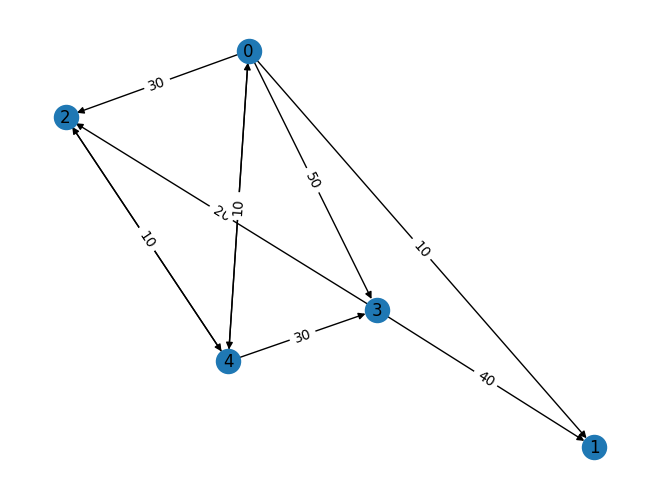

In [ ]:
weight_mat = [
    [0, 10, 30, 50, 10],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 10],
    [0, 40, 20, 0, 0],
    [10, 0, 10, 30, 0]
]


G = nx.from_numpy_array(np.array(weight_mat), create_using=nx.DiGraph)
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.show()

In [29]:
prev, dist = dijkstra(weight_mat, 0)

print(prev, dist)

[-1, 0, 4, 4, 0] [0, 10, 20, 40, 10]
